# Objectif 

L'objectif de ce notebook est de modéliser la propagation dans la zone de la campagne de mesure à Groix dans le cadre du projet Fiberscope. En particulier, on souhaite : 

* Modéliser la réponse impulsionnelle du canal dans la gamme de fréquence d'intérêt, en déduire le temps de réverbération et comparer aux valeurs proposées par Myriam L. dans le rapport préliminaire (modélisation Bellhop)

* Tester différents paramètres du signal source pour identifier la configuration la plus efficace pour mener des essais de localisation à partir du vecteur de RTF. 

Dans le rapport, 6 profils sont considérés. On considère dans un premier temps le profil 1 reliant le point T5 à l'OBS 3. Le guide d'onde est modélisé par un guide de Pekeris dont les propriétés du sédiment sont données par le profil équivalent en distance. 

Données utilisées : 

* Bathymétrie : GEBCO 2021
* SSP 

Coordonnées des points (d'après la fiche prévisionnelle des expérimentations envisagées) -> pos_dm.csv 


In [106]:
import os
import sys
import arlpy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 

from time import time

project_root = "/home/program/ubf_tools"        # Linux TIM
# project_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"  # Windows BAPTISTE
sys.path.append(project_root)

# Load usefull functions
import source.global_constants as g
from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
from propa.ideal_waveguide import (
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    print_arrivals,
)

from propa.kraken_toolbox.src.kraken_testcase import (
    KrakenTestCase,
    DomainProperties,
    SourceProperties,
    ReceiverProperties,
    KrakenProperties,
)
from propa.kraken_toolbox.src.kraken_env import (
    KrakenTopHalfspace,
    KrakenMedium,
    KrakenBottomHalfspace,
    KrakenAttenuation,
    KrakenField,
    Bathymetry,
)
from propa.kraken_toolbox.src.kraken_manager import KrakenManager
from propa.kraken_toolbox.plot_utils import plotshd, plotmode, plotmode_several_freqs
from propa.kraken_toolbox.utils import default_nb_rcv_z
from signals.AcousticComponent import AcousticSource
from source.signal_generator import SignalGenerator
from source.ssp_profiles import SSPProfile
from misc import mult_along_axis

from get_data.cmems import load_data_from_cmems as cmems
from get_data.bathymetry import bathy_profile_extraction as bpe
from cst import N_CORES

pfig = PubFigure()

In [107]:
folder_root = os.path.join(project_root, "propa", "rtf", "rtf_estimation", "xp_fiberscope_groix")
tc_root_dir = os.path.join(project_root, "propa", "kraken_toolbox", "testcases")

img_folder_path = os.path.join(folder_root, "img")
data_folder_path = os.path.join(folder_root, "data")

if not os.path.exists(img_folder_path):
    os.makedirs(img_folder_path)
if not os.path.exists(data_folder_path):
    os.makedirs(data_folder_path)

input_data_root = os.path.join(project_root, "data")
bathy_fpath = os.path.join(input_data_root, "bathy", "GEBCO_2021_sub_ice_topo.nc")

# Select profile
profile = "p4"
if profile == "p1":
    src_pos_id = "t5"
    rcv_pos_id = "obs3"
elif profile == "p4":
    src_pos_id = "t2"
    rcv_pos_id = "obs3"

name = f"xp_fiberscope_groix_{profile}"
title = f"Fiberscope Groix - Profile {profile.upper()}"

# # Dataset path
tf_demo_fpath = os.path.join(data_folder_path, f"tf_demo_{profile}.nc")
tf_prod_fpath = os.path.join(data_folder_path, f"tf_prod_{profile}.nc")
bathy_fpath_csv = os.path.join(data_folder_path, f"bathy_{profile}.csv")

# sig_fpath = os.path.join(data_folder_path, "received_signals.nc")

# Etape 1 : chargement et mise en forme des données nécessaires 

In [108]:
# Load coords of the experiment
df_coords = pd.read_csv(os.path.join(data_folder_path, "pos_deg.csv"), index_col=0)
print(
    f"OBS 3: lon = {df_coords.loc[rcv_pos_id].lon}, lat = {df_coords.loc[rcv_pos_id].lat}"
)
dlat_box = 0.1
dlon_box = 0.1

OBS 3: lon = -3.46, lat = 47.67666666666667


### Bathy

In [109]:
extract_bathy = True

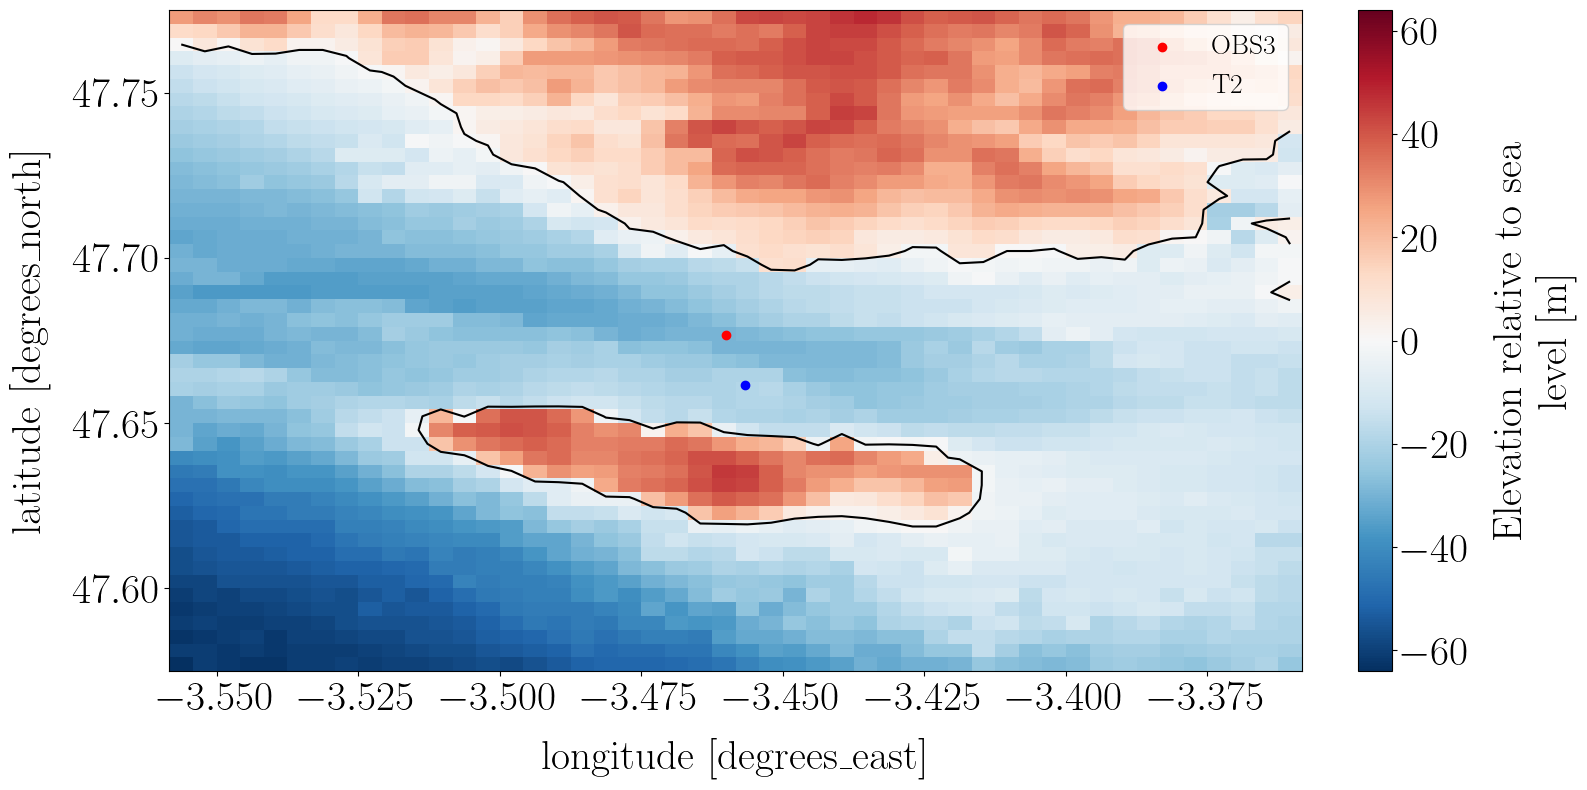

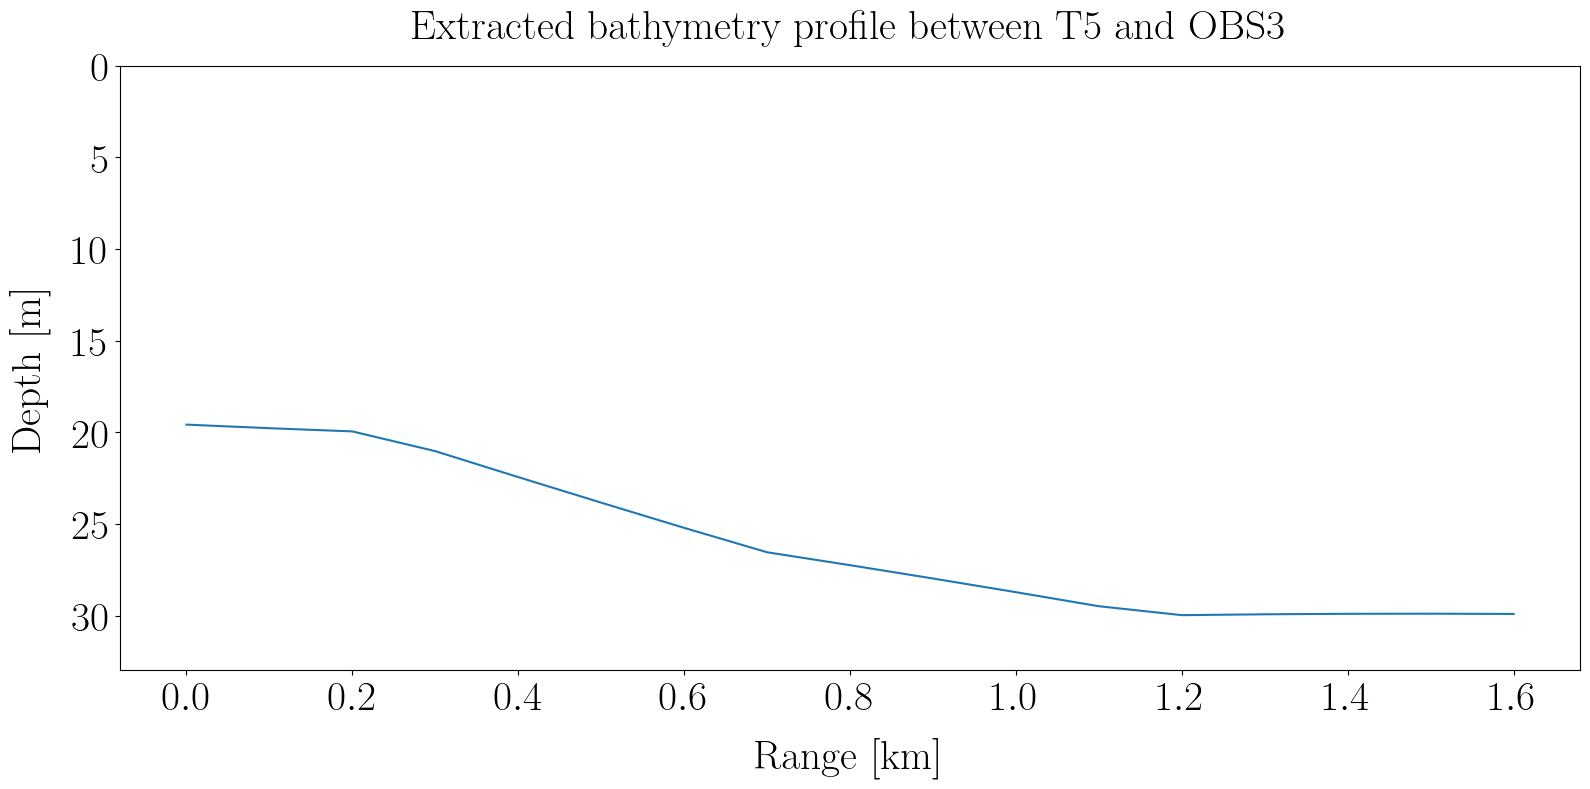

In [110]:

if extract_bathy:
    # Load bathy data
    ds_bathy = xr.open_dataset(bathy_fpath)

    # Slice data to get the area of interest
    ds_bathy = ds_bathy.sel(
        lat=slice(
            df_coords.loc[rcv_pos_id].lat - dlat_box,
            df_coords.loc[rcv_pos_id].lat + dlat_box,
        ),
        lon=slice(
            df_coords.loc[rcv_pos_id].lon - dlon_box,
            df_coords.loc[rcv_pos_id].lon + dlon_box,
        ),
    )

    # Plot elevation
    plt.figure()
    ds_bathy.elevation.plot()
    plt.scatter(
        df_coords.loc[rcv_pos_id].lon,
        df_coords.loc[rcv_pos_id].lat,
        color="red",
        label=rcv_pos_id.upper(),
    )
    plt.scatter(
        df_coords.loc[src_pos_id].lon,
        df_coords.loc[src_pos_id].lat,
        color="blue",
        label=src_pos_id.upper(),
    )

    # Add contours
    plt.contour(
        ds_bathy.lon, ds_bathy.lat, ds_bathy.elevation, levels=[-0], colors="black"
    )
    plt.legend()

    # Extract bathy along the path between OBS3 and T5
    dr = 100
    # Rename variable to suit function input elevation -> bathymetry
    ds_bathy = ds_bathy.rename({"elevation": "bathymetry"})

    range_along_profile, bathymetry_profile = bpe.extract_bathy_profile(
        xr_bathy=ds_bathy,
        start_lat=df_coords.loc[src_pos_id].lat,
        start_lon=df_coords.loc[src_pos_id].lon,
        stop_lat=df_coords.loc[rcv_pos_id].lat,
        stop_lon=df_coords.loc[rcv_pos_id].lon,
        range_resolution=dr,
    )
    # Set positive bathymetry down
    bathymetry_profile = -bathymetry_profile

    # Plot extracted profile
    plt.figure()
    plt.plot(range_along_profile / 1e3, bathymetry_profile)
    plt.xlabel("Range [km]")
    plt.ylabel("Depth [m]")
    plt.title("Extracted bathymetry profile between T5 and OBS3")
    plt.ylim(0, np.max(bathymetry_profile) * 1.1)
    plt.gca().invert_yaxis()

    # Define bathy object for kraken
    bathy_arr = np.array([range_along_profile * 1e-3, bathymetry_profile]).T
    # Convert to datafram
    df_bathy = pd.DataFrame(bathy_arr)
    # Save to csv
    df_bathy.to_csv(bathy_fpath_csv, index=False, header=False)

In [111]:
# Dummy testcase to init directories
# name = "xp_fiberscope_groix_p1"
dummmy_tc = KrakenTestCase(
    name=name,
    root_dir=tc_root_dir,
)

In [112]:

bathy = Bathymetry(
    data_file=bathy_fpath_csv,
    interpolation_method="linear",
    units="km",
)

### SSP 

In [113]:
use_cmems = False

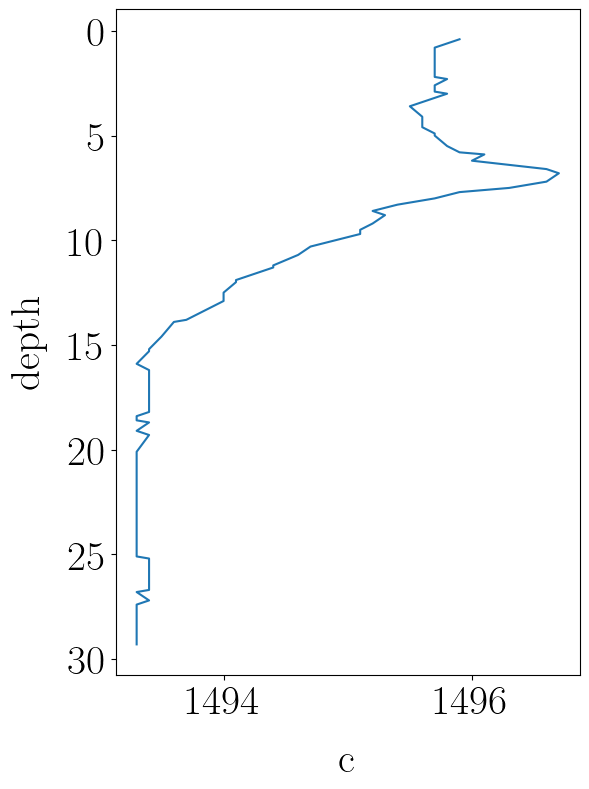

In [114]:
if use_cmems:

    download_cmems_data = False

    # dataset_id = "cmems_mod_glo_phy_anfc_0.083deg_PT1H-m"
    # dataset_version = "202406"
    # start_datetime = "2022-09-15T00:00:00"
    # end_datetime = "2022-09-16T00:00:00"

    dataset_id = "cmems_mod_glo_phy_my_0.083deg_P1D-m"
    dataset_version = "202311"
    start_datetime = "2020-09-15T00:00:00"
    end_datetime = "2020-09-16T00:00:00"

    # Set file name
    fname = f"cmems_thetao_so_{dataset_id.split('_')[-1]}_{start_datetime[:10]}_{end_datetime[:10]}.nc"

    if download_cmems_data:
        data_request = dict(
            dataset_id=dataset_id,
            dataset_version="202406",
            variables=[
                "so",
                "thetao",
            ],
            minimum_longitude=df_coords.loc[rcv_pos_id].lon - dlon_box,
            maximum_longitude=df_coords.loc[rcv_pos_id].lon + dlon_box,
            minimum_latitude=df_coords.loc[rcv_pos_id].lat - dlat_box,
            maximum_latitude=df_coords.loc[rcv_pos_id].lat + dlat_box,
            start_datetime=start_datetime,
            end_datetime=end_datetime,
            minimum_depth=0,
            maximum_depth=100,
            output_dir=data_folder_path,
            output_filename=fname,
            force_download=True,
        )
        ds_cmems = cmems.load_data(data_request)

    else:
        pass

    # Load existing file
    fpath = os.path.join(data_folder_path, fname)
    ds_cmems = xr.open_dataset(fpath)

    # Plot spatial coverage
    plt.figure()
    ds_cmems.thetao.isel(depth=0, time=0).plot()

    # Add points
    plt.scatter(
        df_coords.loc[rcv_pos_id].lon,
        df_coords.loc[rcv_pos_id].lat,
        color="red",
        label=rcv_pos_id.upper(),
    )
    plt.scatter(
        df_coords.loc[src_pos_id].lon,
        df_coords.loc[src_pos_id].lat,
        color="blue",
        label=src_pos_id.upper(),
    )
    plt.legend()

    # Add bathy contours
    plt.contour(
        ds_bathy.lon, ds_bathy.lat, ds_bathy.bathymetry, levels=[0], colors="black"
    )

    # Extract data profile at the location of the emitter (T5)
    ds_cmems_t5 = ds_cmems.sel(
        longitude=df_coords.loc[src_pos_id].lon,
        latitude=df_coords.loc[src_pos_id].lat,
        method="nearest",
    )
    # Extrat data profile at the location of the receiver (OBS3)
    ds_cmems_obs3 = ds_cmems.sel(
        longitude=df_coords.loc[rcv_pos_id].lon,
        latitude=df_coords.loc[rcv_pos_id].lat,
        method="nearest",
    )

    # Get associated ssp
    c_t5 = arlpy.uwa.soundspeed(
        temperature=ds_cmems_t5.thetao.isel(time=0).values,
        salinity=ds_cmems_t5.so.isel(time=0).values,
        depth=ds_cmems_t5.depth.values,
    )
    c_obs3 = arlpy.uwa.soundspeed(
        temperature=ds_cmems_obs3.thetao.isel(time=0).values,
        salinity=ds_cmems_obs3.so.isel(time=0).values,
        depth=ds_cmems_obs3.depth.values,
    )

    # Put c in a dedicated xarray dataset
    ds_ssp_t5 = xr.Dataset(
        {"c": (("depth"), c_t5)}, coords={"depth": ds_cmems_t5.depth.values}
    )
    ds_ssp_obs3 = xr.Dataset(
        {
            "c": (
                ("depth"),
                c_obs3,
            )
        },
        coords={"depth": ds_cmems_obs3.depth.values},
    )

    # Plot celerity profiles
    plt.figure(figsize=(6, 8))
    ds_ssp_t5.c.plot(y="depth", label="T-T5")
    ds_ssp_obs3.c.plot(y="depth", label="T-OBS3")
    plt.gca().invert_yaxis()
    plt.xlabel("Sound speed [m/s]")
    plt.ylabel("Depth [m]")

    ds_ssp = ds_ssp_obs3
else:
    fname = "svp_1159_04112017.csv"
    fpath = os.path.join(data_folder_path, fname)
    df_ssp_xp = pd.read_csv(fpath)

    # Define xarray dataset
    ds_ssp_xp = xr.Dataset(
        {"c": (("depth"), df_ssp_xp.ssp.values)},
        coords={"depth": df_ssp_xp.d.values},
    )
    ds_ssp_xp.attrs["date"] = fname.split("_")[1]

    # Plot celerity profiles
    plt.figure(figsize=(6, 8))
    ds_ssp_xp.c.plot(y="depth", label=ds_ssp_xp.attrs["date"])
    # reverse y axis
    plt.gca().invert_yaxis()

    ds_ssp = ds_ssp_xp

# Etape 2 : définition du cas test 

## Paramètres du guide d'onde de Pekeris

D'après le rapport du SHOM le tracé de rayon est effectué avec un sédiment sable (cf P;14 en dessous de la figure 17). 

In [115]:
# Waveguide geometry
depth = np.ceil(bathy.bathy_depth.max())  # m
zmin = 0
zmax = depth
max_range_km = bathy.bathy_range.max()
rmin = 0
rmax = max_range_km * 1e3

print(f"Waveguide depth: {depth} m")
print(f"Waveguide range: {max_range_km} km")

# Sediment
bott_props = g.sand_properties
print(f"Sediment properties: {bott_props}")

Waveguide depth: 30.0 m
Waveguide range: 1.6 km
Sediment properties: {'rho': 1.9000000000000001, 'c_p': 1650, 'c_s': 0.0, 'a_p': 0.8, 'a_s': 0.0}


## Paramètres de la source 

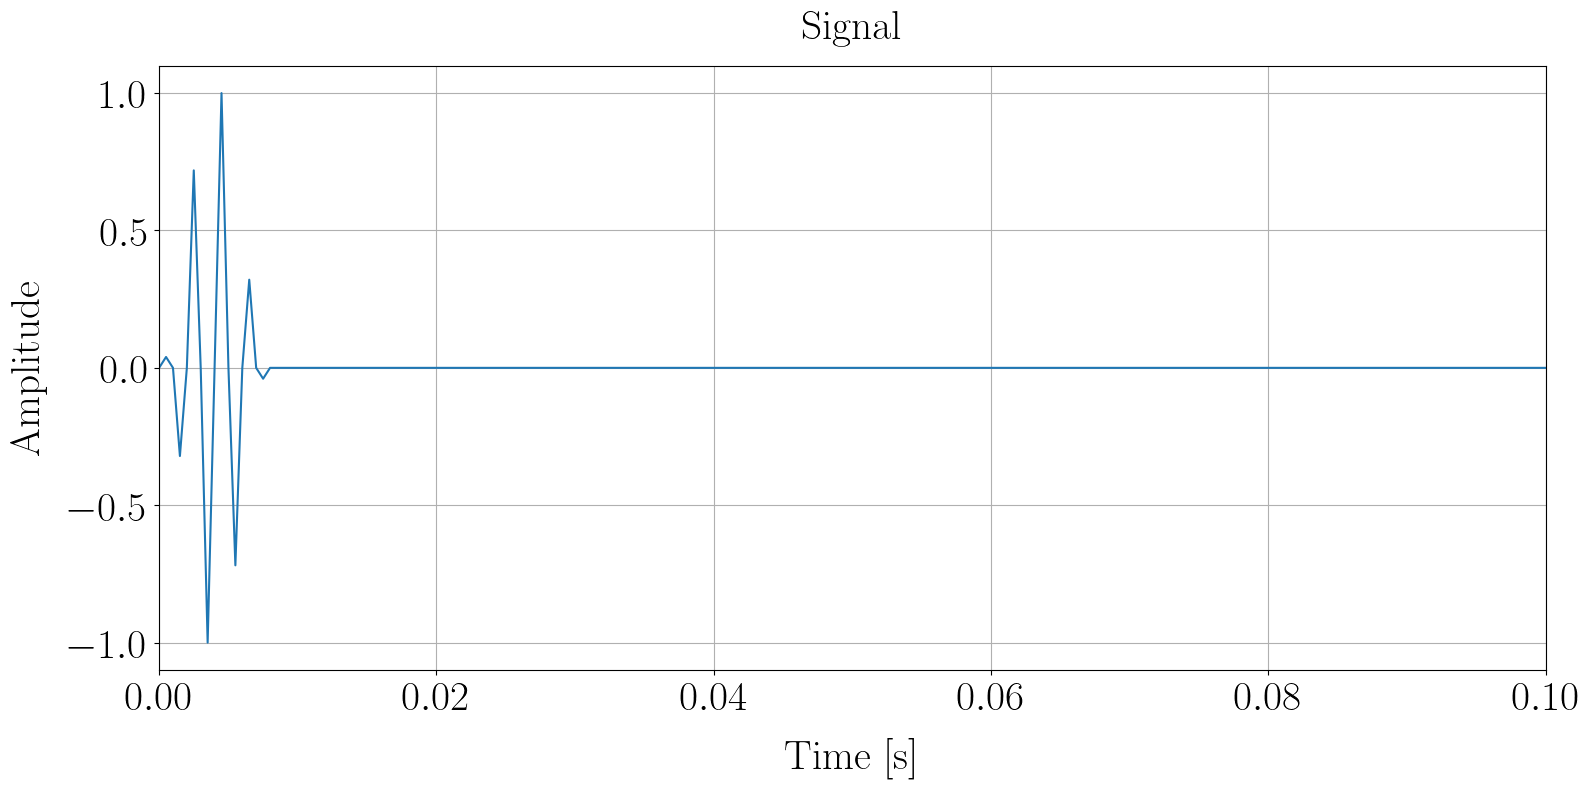

In [116]:
src_depth = 5 # m
src_min_freq = 200 # Hz
src_max_freq = 1000 # Hz
src_fs = 2000  # Hz
src_signal_duration = 4  # s

# Create dummy signal to make it easy to run kraken simulation
fc = src_max_freq / 2  # Hz
sg = SignalGenerator()
s, t = sg.pulse(T=src_signal_duration, fc=fc, fs=src_fs, t0=0)

s = sg.normalize_sig(s, normalize="max")
# Plot time serie
sg.plot_signal(t, s)
plt.gca().set_xlim([0, 0.1])

src = AcousticSource(
    signal=s,
    time=t,
    name="Pulse",
    waveguide_depth=depth,
    window=None,
    nfft=2 ** int(np.log2(s.size) + 1),
)

## Paramètres généraux et objects KrakenEnv

In [117]:
# Common properties
# name = "xp_fiberscope_groix_p1"
title = "Fiberscope Groix - Profile P1"

In [118]:
# Set domain properties
domain_properties = DomainProperties(
    zmin=zmin, zmax=zmax, rmin=rmin, rmax=rmax, unit="m"
)

In [119]:
# Set source properties
src_properties = SourceProperties(
    src_type="point_source", src_depth=src_depth, freq=src.kraken_freq
)

In [120]:
# Set receiver properties : needs to cover the whole water domain
rcv_z_min = zmin
rcv_z_max = zmax * 2
rcv_properties = ReceiverProperties(
    zmin=rcv_z_min, zmax=rcv_z_max, rmin=rmin, rmax=rmax, unit="m"
)

In [121]:
# Set layer properties
nmedia = 2

top_hs = KrakenTopHalfspace(
    boundary_condition="vacuum",
    halfspace_properties=None,
    twersky_scatter_properties=None,
)

bott_hs = KrakenBottomHalfspace(
    boundary_condition="acousto_elastic",
    sigma=0.0,
    halfspace_properties=bott_props,
    fmin=src.kraken_freq.min(),
    alpha_wavelength=10,
)

In [122]:
# Set attenuation properties
att = KrakenAttenuation(units="dB_per_wavelength", use_volume_attenuation=False)

In [123]:
# Set SSP object for kraken
z_ssp = ds_ssp.depth.values
c = ds_ssp.c.values


ssp = SSPProfile(z=z_ssp, c=c)

In [124]:
# Create the medium = water column layer
medium = KrakenMedium(
    ssp_interpolation_method="C_linear",
    z_ssp=ssp.z,
    c_p=ssp.c,
    c_s=0.0,
    rho=g.rho_w * 1e-3,
    a_p=0.0,
    a_s=0.0,
    nmesh=0,
    sigma=0.0,
)

In [125]:
# Set field properties
bott_hs.derive_sedim_layer_max_depth(domain_properties.zmax_m)
max_rcv_depth = bott_hs.sedim_layer_max_depth
n_rcv_z = default_nb_rcv_z(
    fmax=src.kraken_freq.max(), max_depth=max_rcv_depth, n_per_l=10
)

min_phase_speed = 1400
max_phase_speed = 1800

field = KrakenField(
    phase_speed_limits=[min_phase_speed, max_phase_speed],
    src_depth=[src_properties.depth],
    n_rcv_z=n_rcv_z,
    rcv_z_min=0,
    rcv_z_max=max_rcv_depth,
    rcv_r_max=0.0,
)

In [126]:
# Set kraken properties
# Number of receiver depths / ranges (flp file)
lambda_min = g.c0 / src_max_freq
dr = lambda_min / 10
dz = lambda_min / 10
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

In [127]:
# Define testcase 
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

## Run demo pour vérifier que la simu fonctionne 

In [128]:
# Test with just a few caracteristics frequencies
run_kraken_demo = False
demo_freq = [63, 250, 750]
if run_kraken_demo:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=demo_freq
    )

In [129]:
if run_kraken_demo:
    # Store pressure field as netcdf using xarray
    pressure_field_ = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf_demo = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field_)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field_)),
        ),
        coords=dict(
            f=demo_freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title="Kraken output for Fiberscope Groix - Profile P1 - Demo",
            description="Transfer functions computed using Kraken for the Fiberscope Groix experiment - Profile P1.",
            # date_created=np.datetime64("now"),
            note="Demo dataset with limited frequencies.",
            type="demo",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )
    # Save to netcdf
    ds_tf_demo.to_netcdf(tf_demo_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf_demo = xr.open_dataset(tf_demo_fpath)

In [130]:
ds_tf_demo

<xarray.Dataset> Size: 205MB
Dimensions:  (f: 3, z: 401, r: 10667)
Coordinates:
  * f        (f) int32 12B 63 250 750
  * z        (z) float32 2kB 0.0 0.15 0.3 0.45 0.6 ... 59.55 59.7 59.85 60.0
  * r        (r) float64 85kB 0.0 0.1875 0.375 0.5625 ... 2e+03 2e+03 2e+03
Data variables:
    tf_real  (f, z, r) float64 103MB ...
    tf_imag  (f, z, r) float64 103MB ...
Attributes:
    title:            Kraken output for Fiberscope Groix - Profile P1 - Demo
    description:      Transfer functions computed using Kraken for the Fibers...
    note:             Demo dataset with limited frequencies.
    type:             demo
    fs:               2000
    signal_duration:  4

### Plot de quelques résultats 

In [131]:
# fréquence de coupure du mode m
m = 20
f_0m = ((m - 0.5) * g.c0) / (2 * depth * np.sqrt(1 - (g.c0 / bott_props["c_p"]) ** 2))
print(f"Cut-off frequency of mode {m} : {f_0m:.2f} Hz")

Cut-off frequency of mode 20 : 1170.19 Hz


In [132]:
# lfig = LargeFigure()

# f_visu = 800  # Frequency to visualize
# mode_fpath = os.path.join(k_tc.io_files_dir, "parallel_working_dir", "child_process_24388", k_tc.env.filename)
# plotmode(
#     mode_fpath,
#     freq=[f_visu],
#     modes=[1, 2, 3, 25],
#     bathy_depth=k_tc.bathy.bathy_depth[0],
#     normalize_mode=False,
# )

# fig = plt.gcf()
# plt.ylim([depth*3, 0])
# fig.suptitle(f"f = {f_visu} Hz")

# # # Save figure as pdf
# # fpath = os.path.join(img_folder_path, f"{name}_4modes.pdf")
# # plt.savefig(fpath, dpi=300)

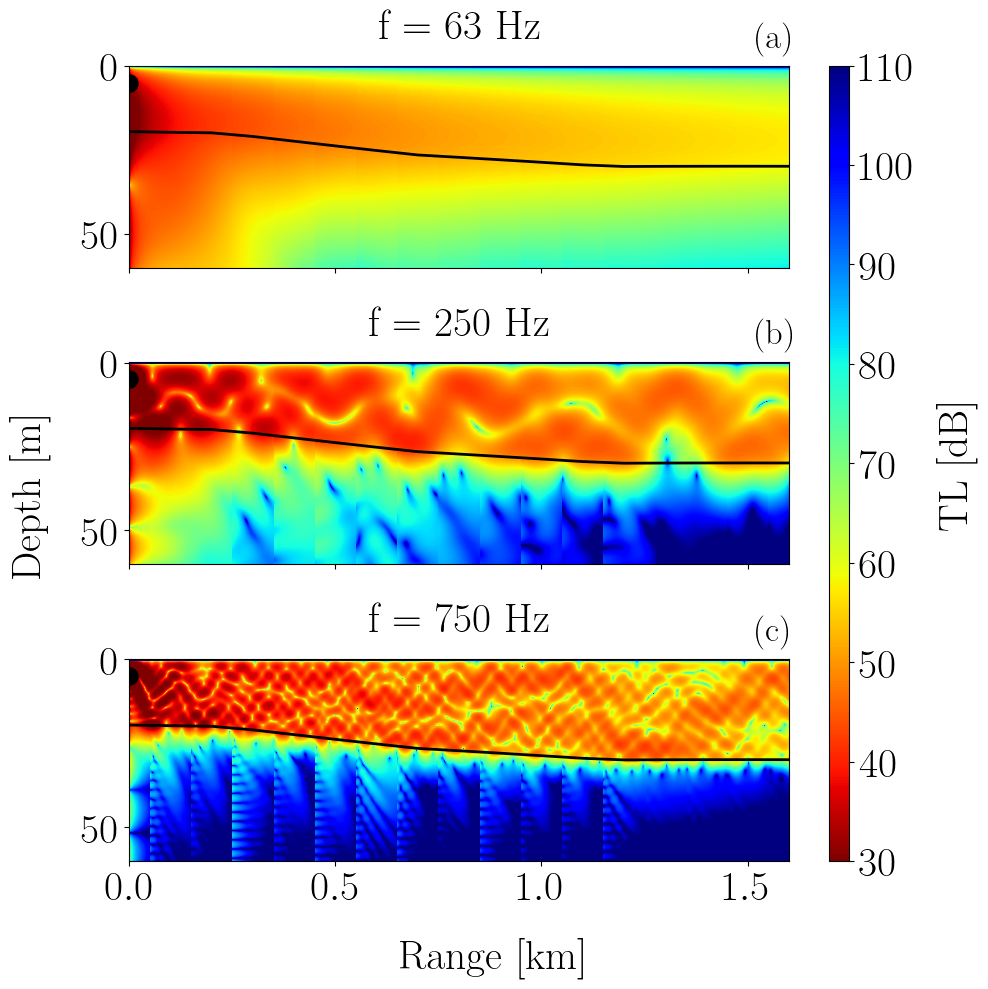

In [133]:
lfig = LargeFigure(size=(16, 7.5))

# Plot tl at a single frequency
tf_demo = ds_tf_demo.tf_real + 1j * ds_tf_demo.tf_imag  # (nf, nz, nr)
freq_plot = demo_freq
p_field = tf_demo.sel(f=freq_plot, method="nearest").values
p_field[(p_field == 0) | np.isnan(p_field)] = 1e-20 
tl = - 20 * np.log10(np.abs(p_field)) 
# tlmax = np.percentile(tl, 95)
# tlmin = np.percentile(tl, 1)

tlmax = 110
tlmin = 30

# Plot TL for each number of modes
fig, axs = plt.subplots(len(freq_plot), figsize=(10, 10), sharex=True)
abcd_labels = ["a", "b", "c"]
for i, fp in enumerate(freq_plot):
    p_field = p_field[i, ...]
    title = f"f = {fp} Hz"

    # Plot TL
    im = axs[i].pcolormesh(
        tf_demo.r * 1e-3,
        tf_demo.z,
        tl[i],
        cmap="jet_r",
        vmin=tlmin,
        vmax=tlmax,
        rasterized=True,
    )

    # Add source position
    if src_depth is not None:
        axs[i].scatter(
            0,
            src_depth,
            color="k",
            marker="o",
            s=150,
        )
    axs[i].set_title(title)
    axs[i].invert_yaxis()

    # Add a, b, c labels
    axs[i].text(
        0.95,
        1.05,
        f"({abcd_labels[i]})",
        transform=axs[i].transAxes,
        fontsize=25,
        fontweight="bold",
        va="bottom",
    )

    # Add bathy
    axs[i].plot(bathy.bathy_range, bathy.bathy_depth, color="k", linewidth=2)
    # Limit to bathy range 
    axs[i].set_xlim([0, bathy.bathy_range.max()])

fig.supxlabel("Range [km]")
fig.supylabel("Depth [m]")

# Add common colorbar
cbar = fig.colorbar(im, ax=axs, orientation="vertical", pad=0.05, aspect=40)
cbar.set_label("TL [dB]")


# # Save figure as pdf
# fpath = os.path.join(img_folder_path, f"{name}_tl_3freqs.pdf")
# plt.savefig(fpath)

## Calcul des fonctions de Green du guide d'onde étudié

In [134]:
# Reset kraken properties with much lower output field resolution for memory issues
# Number of receiver depths / ranges (flp file)
lambda_min = g.c0 / src_max_freq
dr = 200
dz = 5
nr_flp = int(rmax / dr) + 1
nz_flp = int(rcv_z_max / dz) + 1

kraken_properties = KrakenProperties(
    mode_coupling="coupled",
    mode_addition="coherent",
    n_mode=100,
    nr=nr_flp,
    nz=nz_flp,
    nmedia=nmedia,
    top_hs=top_hs,
    bott_hs=bott_hs,
    att=att,
    medium=medium,
    field=field,
)

# re-Define testcase to update flp props 
k_tc = KrakenTestCase(
    name=name,
    title=title,
    root_dir=tc_root_dir,
    bathy=bathy,
    domain_properties=domain_properties,
    src_properties=src_properties,
    rcv_properties=rcv_properties,
    kraken_properties=kraken_properties,
)

In [135]:
# Kraken compute otpion
run_kraken = False
# run_kraken = True

In [136]:
run_freq = k_tc.src.freq[
    (k_tc.src.freq >= src_min_freq) & (k_tc.src.freq <= src_max_freq)
]
f_before = src.positive_freq[src.positive_freq < run_freq.min()]
pad_before = f_before.size
f_after = src.positive_freq[src.positive_freq > run_freq.max()]
pad_after = f_after.size

In [137]:
# Evaluate expected cpu time
if run_kraken:
    nproc = N_CORES

    run_freq_cpu_test = run_freq[-nproc :]      # Test with highest frequencies -> worst case scenario
    nf_cpu_test = run_freq_cpu_test.size

    # Run a quick test to estimate cpu time
    t0 = time()
    km = KrakenManager(parallel=False, verbose=True)
    _, _ = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq_cpu_test
    )
    cpu_time = time() - t0

    avg_cpu_time_per_freq = cpu_time / nf_cpu_test
    estimated_cpu_time = avg_cpu_time_per_freq * run_freq.size / nproc

    print(
        f"Max expected cpu time: {estimated_cpu_time / 60:.2f} min for {run_freq.size} frequencies on {nproc} cores"
    )


In [138]:

if run_kraken:
    km = KrakenManager(parallel=True, verbose=True)
    pressure_field, field_pos = km.runkraken(
        env=k_tc.env, flp=k_tc.flp, frequencies=run_freq
    )

    # Pad with zeros to get the full frequency band
    pad_tuple = ((pad_before, pad_after),) + ((0, 0),)*(len(pressure_field.shape)-1)
    pressure_field = np.pad(pressure_field, pad_tuple, mode="constant", constant_values=0)

## Sauvergarde des fonctions de transfert du guide d'onde 

In [139]:
if run_kraken:
    # Store pressure field as netcdf using xarray
    pressure_field = np.squeeze(pressure_field)  # Remove singleton dimensions if any
    ds_tf = xr.Dataset(
        data_vars=dict(
            tf_real=(["f", "z", "r"], np.real(pressure_field)),
            tf_imag=(["f", "z", "r"], np.imag(pressure_field)),
        ),
        coords=dict(
            f=src.positive_freq,
            z=field_pos["r"]["z"],
            r=field_pos["r"]["r"],
        ),
        attrs=dict(
            title="Kraken output for Fiberscope Groix - Profile P1 - Prod",
            description="Transfer functions computed using Kraken for the Fiberscope Groix experiment - Profile P1.",
            # date_created=np.datetime64("now"),
            note="Production dataset with all frequencies in the band of interest 200 - 1000 Hz.",
            type="prod",
            fs=src_fs,
            signal_duration=src_signal_duration,
        ),
    )
    # Save to netcdf
    ds_tf.to_netcdf(tf_prod_fpath)
else:
    # Load transfer functions from netcdf
    ds_tf = xr.open_dataset(tf_prod_fpath)

## Visualisation du signal propagé

In [140]:
# run_this_section = False
run_this_section = True

In [141]:
rmin_visu = 0 * 1e3  # Minimum range for visualization
rmax_visu = bathy.bathy_range.max() * 1e3  # Maximum range for visualization
ds_tf_pulse = ds_tf.sel(r=slice(rmin_visu, rmax_visu))  # Select receivers at required range
rcv_range = ds_tf_pulse.r.values

delays = rcv_range / g.c0
rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [142]:
sig_fpath = os.path.join(data_folder_path, "propagated_pulse.nc")
if run_this_section:
    # Source spectrum
    Sf = src.positive_spectrum

    # Derive delay for each receiver
    tau_rcv = ds_tf_pulse.r.min().values / g.c0
    # tau_rcv = target_range / g.c0

    tf = ds_tf_pulse.tf_real + 1j * ds_tf_pulse.tf_imag  # (nf, nz, nr)

    # Derive received spectrum (Y = SH)
    k0 = 2 * np.pi * ds_tf_pulse.f.values / g.c0
    norm_factor = np.exp(1j * k0) / (4 * np.pi)

    # # Derive delay factor to take into account the propagation time
    delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_pulse.f.values)  # (nf,)

    y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

    nfft_inv = (
        4 * src.nfft
    )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
    T_tot = 1 / src.df
    dt = T_tot / nfft_inv
    time_vector = np.arange(0, T_tot, dt)

    # FFT inv to get signal
    y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
    y_t = np.real(y_t)  # Keep only real part

    # Build dataset to save
    ds_sig = xr.Dataset(
        coords=dict(
            t=time_vector,
            z=ds_tf_pulse.z,
            r=ds_tf_pulse.r,
        ),
        data_vars=dict(
            s=(["t", "z", "r"], y_t),
        ),
    )

    # Save dataset
    ds_sig.to_netcdf(sig_fpath)
else:
    # Load dataset
    ds_sig = xr.open_dataset(sig_fpath)

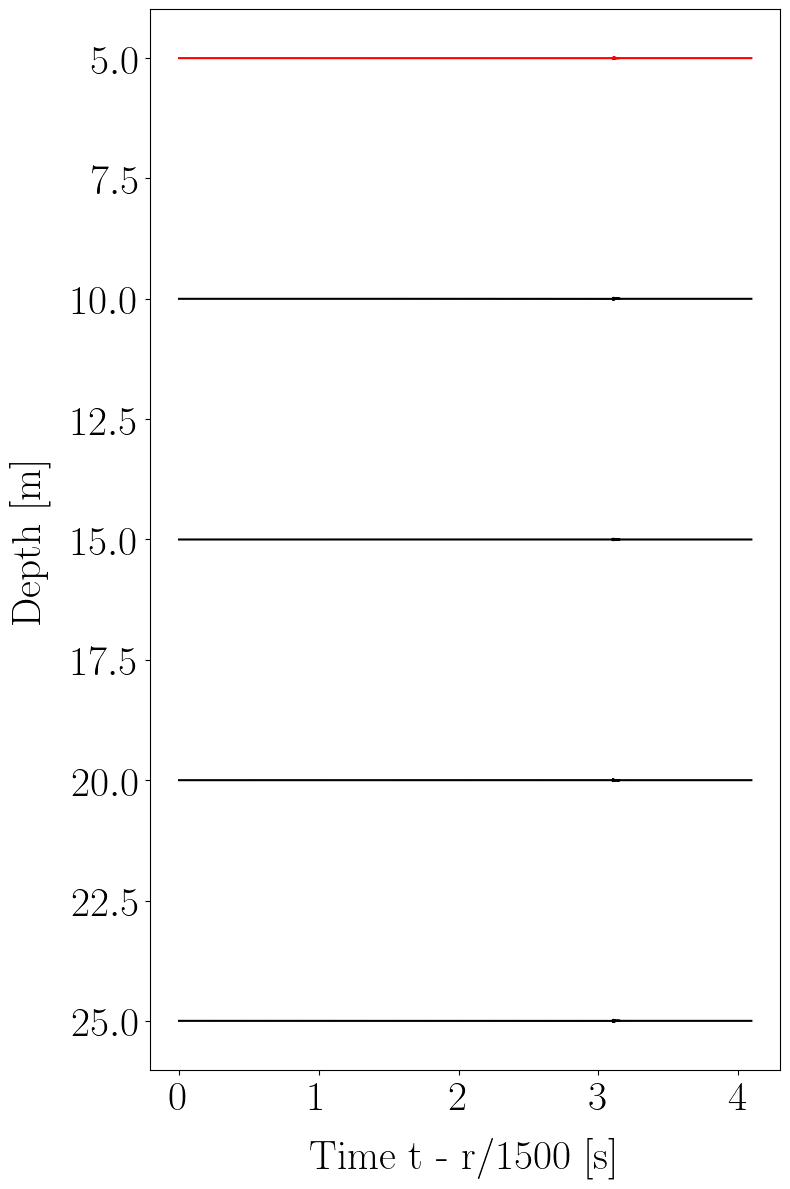

In [143]:
range_plot = np.array([3 * 1e3])
dz = 5
depth_plot = np.arange(dz, bathy.bathy_depth.max(), dz)  # Depths to plot

# Scale for visualization
max_amplitude = ds_sig.s.max().values
alpha_dilatation = 1 * dz 
ds_sig["s"] = ds_sig.s / max_amplitude * alpha_dilatation

# Roll over time axis to start at zero
tau_roll = (
    range_plot[0] - ds_sig.r.min().values
) / g.c0  # Roll time axis to start at zero
ts = ds_sig.t.diff("t").values[0]
idx_tau_roll = int(tau_roll / ts)
sig_roll = ds_sig.s.roll(t=-idx_tau_roll, roll_coords=False)

z_offset = depth_plot[1] - depth_plot[0]
for ir, r in enumerate(range_plot):
    plt.figure(figsize=(8, 12))
    for iz, z in enumerate(depth_plot):
        sig = sig_roll.sel(z=z, r=r, method="nearest") + (iz + 1) * z_offset
        if z == src_depth:
            sig.plot(color="r", label="Source depth")
        else:
            sig.plot(color="k")

    # Revert y-axis
    ax = plt.gca()
    ax.invert_yaxis()
    # plt.xlim([0, 1])
    plt.xlabel(f"Time  t - r/{g.c0} [s]")
    plt.ylabel("Depth [m]")
    plt.title(
        "",
    )
    # Save figure as pdf
    fpath = os.path.join(img_folder_path, f"{name}_received_signals_{range_plot[0]}m.pdf")
    plt.savefig(fpath)

(0.0, 0.5)

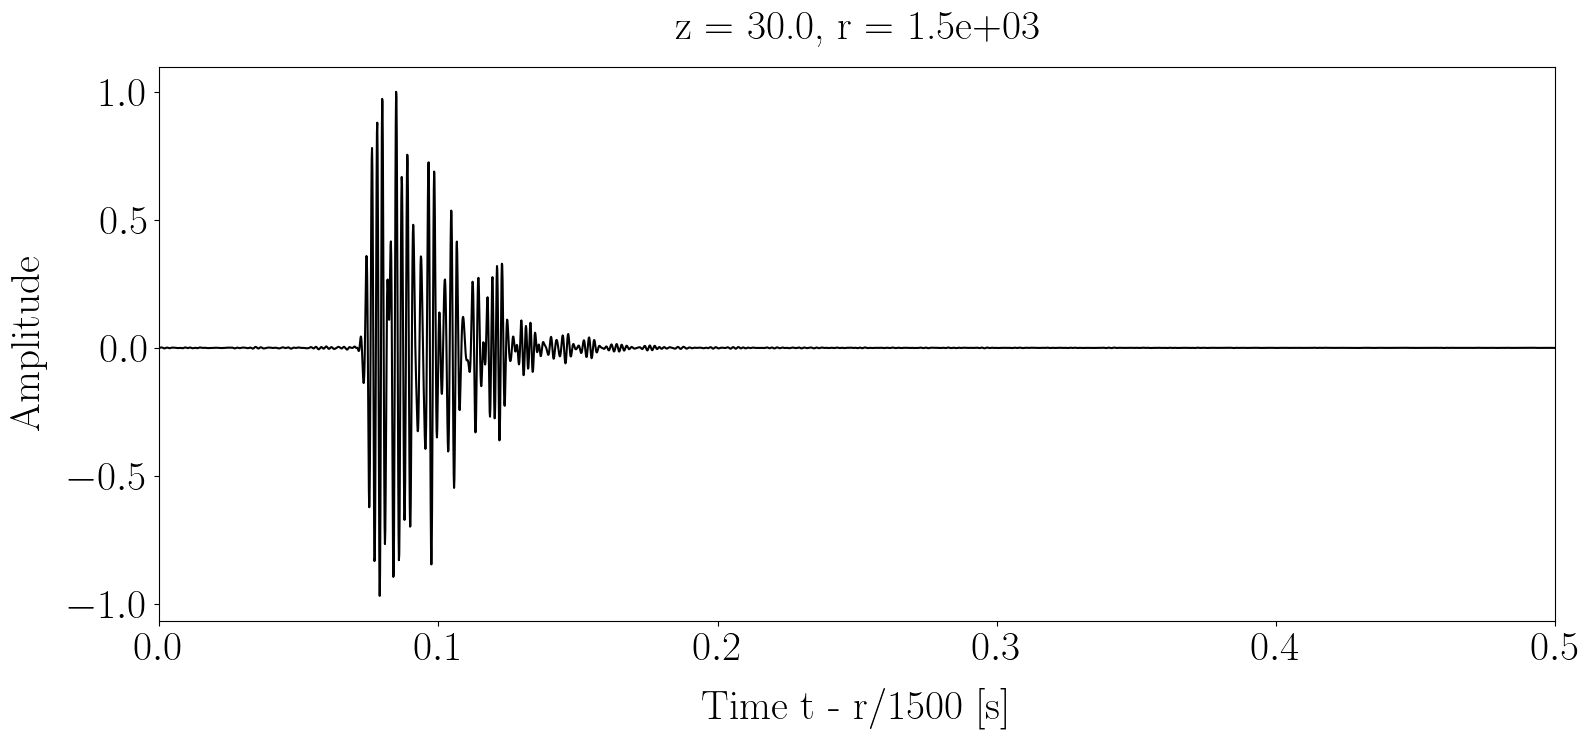

In [155]:
z_plot = 30
r_plot =  bathy.bathy_range.max() * 1e3
ts = ds_sig.t.diff("t").values[0]
tau_roll = (r_plot - ds_sig.r.min().values) / g.c0  # Roll time axis to start at zero
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

sig = ds_sig.s.sel(r=r_plot, z=z_plot, method="nearest")
sig = sig / sig.max().values
sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
sig_roll.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("Amplitude")
plt.xlim([0,0.5])

Window duration for RMS: 0.01 s


Text(0.5, 1.0, '')

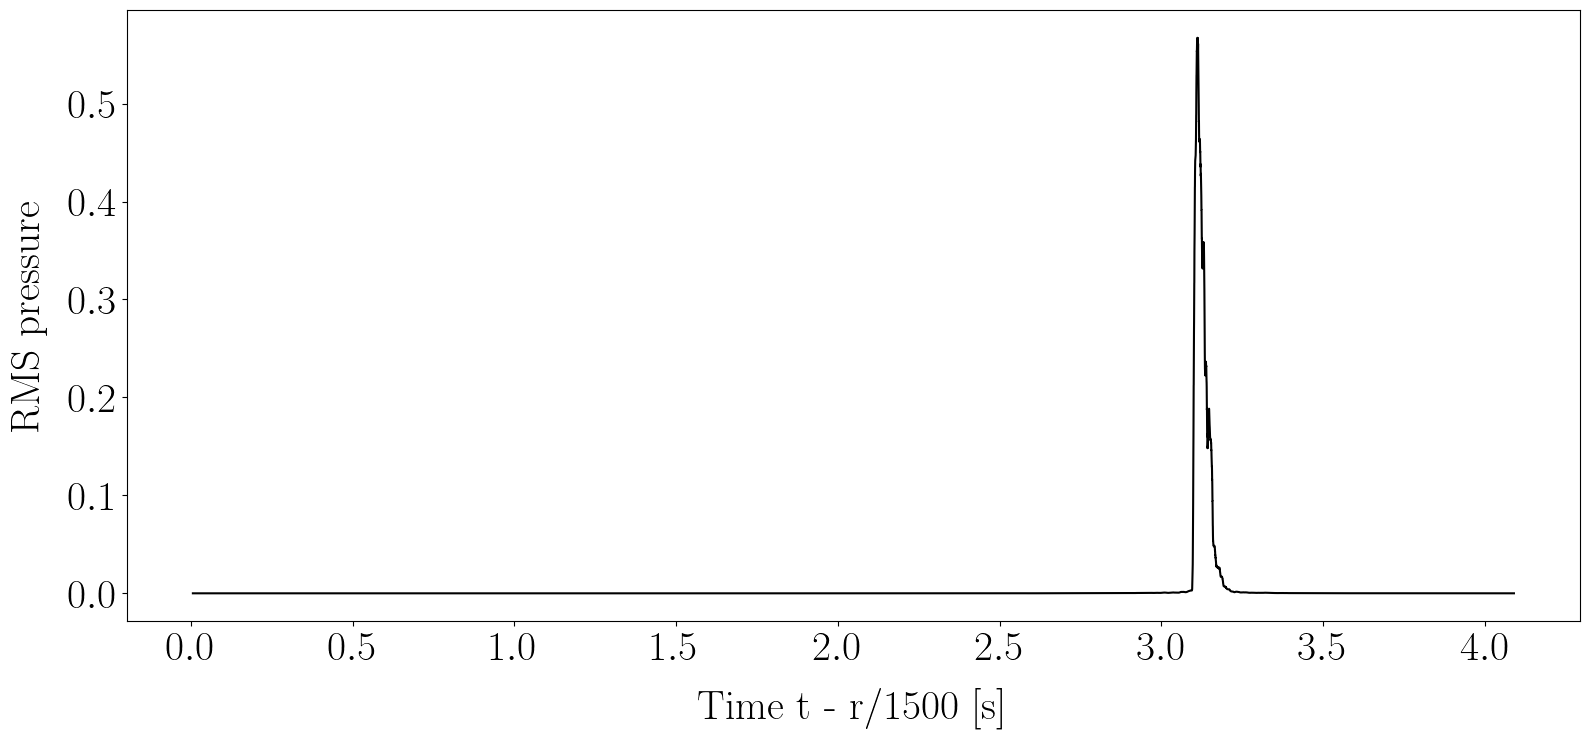

In [145]:
# Derive prms
p = sig_roll
t_win = 100
# print(f"Window size for RMS: {t_win} samples")
print(f"Window duration for RMS: {t_win * ts:.2f} s")
p2_roll = (p**2).rolling(t=t_win, center=True).mean()  
p_rms = np.sqrt(p2_roll)

# Plot p_rms
plt.figure()
p_rms.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("RMS pressure")
plt.title("")
# plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts

Text(0.5, 1.0, '')

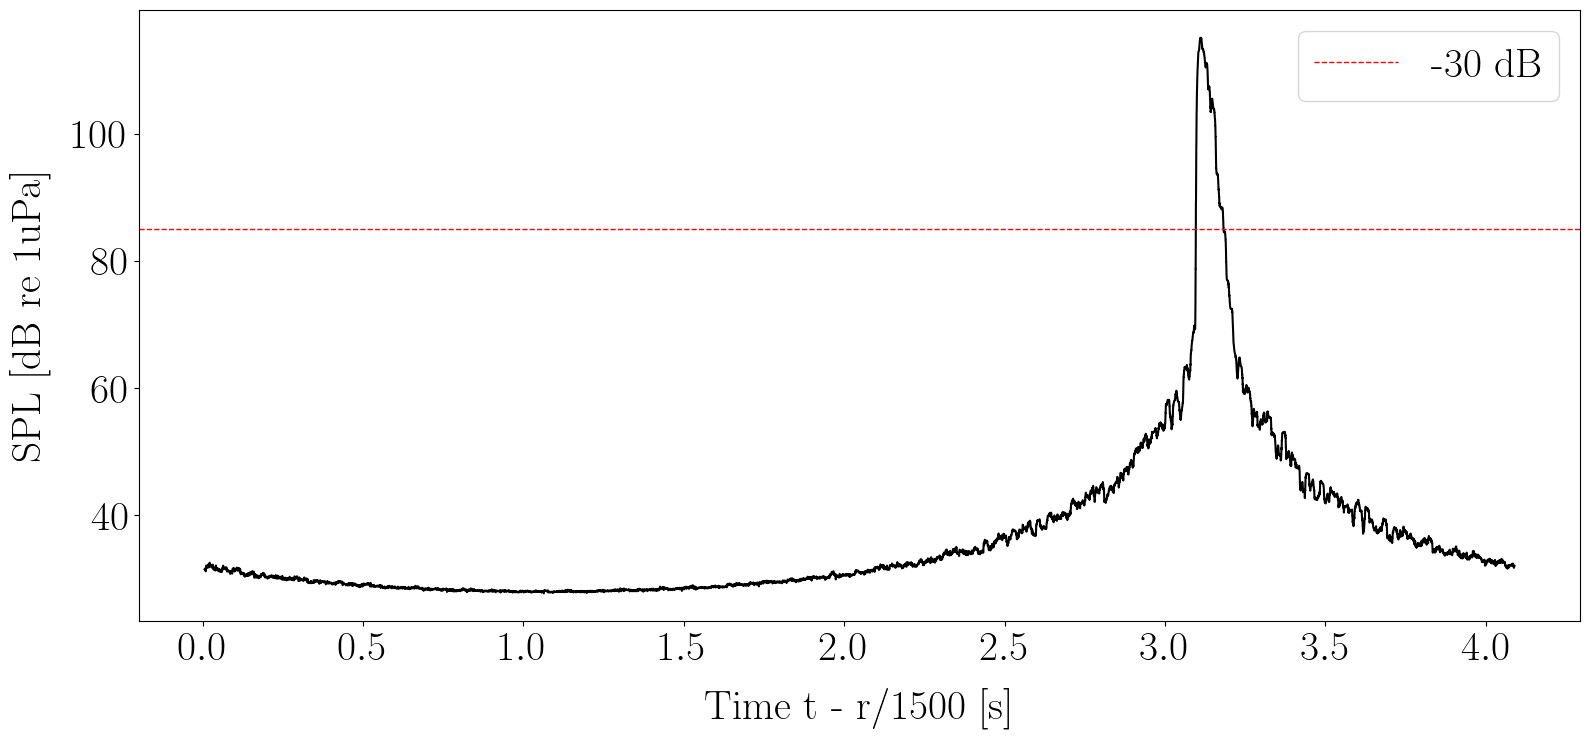

In [146]:
# Derive SPL
# p_rms /= p_rms.max().values
spl = 20 * np.log10(p_rms / g.p0)

# Plot spl
spl.plot(color="k")

# Add threshold line
threshold = -30  # Threshold in dB
th = np.max(spl).values + threshold
plt.axhline(
    y=th,
    color="r",
    linestyle="--",
    linewidth=1,
    label=f"{threshold} dB",
)

# plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("SPL [dB re 1uPa]")
plt.legend()
plt.title("")

# # Save figure as pdf
# fpath = os.path.join(img_folder_path, f"{name}_ir_spl_{r_plot}m.pdf")
# plt.savefig(fpath)

# Visualisation de la réponse impulsionnelle

In [147]:
# run_this_section = False
run_this_section = True

In [148]:
rmin_visu = 0 * 1e3  # Minimum range for visualization
rmax_visu = bathy.bathy_range.max() * 1e3  # Maximum range for visualization
ds_tf_ir = ds_tf.sel(
    r=slice(rmin_visu, rmax_visu)
)  # Select receivers at required range
rcv_range = ds_tf_ir.r.values

delays = rcv_range / g.c0
rcv_depth = np.linspace(k_tc.flp.rcv_z_min, k_tc.flp.rcv_z_max, k_tc.flp.n_rcv_z)

In [149]:
ir_fpath = os.path.join(data_folder_path, "ir.nc")

if run_this_section:
    # Source spectrum
    Sf = src.positive_spectrum
    # Set Sf to unity to get the impulse response 
    Sf[:] = 1

    # Derive delay for each receiver
    tau_rcv = ds_tf_ir.r.min().values / g.c0
    # tau_rcv = target_range / g.c0

    tf = ds_tf_ir.tf_real + 1j * ds_tf_ir.tf_imag  # (nf, nz, nr)

    # Derive received spectrum (Y = SH)
    k0 = 2 * np.pi * ds_tf_ir.f.values / g.c0
    norm_factor = np.exp(1j * k0) / (4 * np.pi)

    # # Derive delay factor to take into account the propagation time
    delay_rcv = np.exp(1j * 2 * np.pi * tau_rcv * ds_tf_ir.f.values)  # (nf,)

    y_f = mult_along_axis(tf, Sf * norm_factor * delay_rcv, axis=0)

    nfft_inv = (
        4 * src.nfft
    )  # according to Jensen et al. (2000) p.616 : dt < 1 / (8 * fmax) for visual inspection of the propagated pulse
    T_tot = 1 / src.df
    dt = T_tot / nfft_inv
    time_vector = np.arange(0, T_tot, dt)

    # FFT inv to get signal
    y_t = np.fft.irfft(y_f, axis=0, n=nfft_inv)  # (nt, nz, nr)
    y_t = np.real(y_t)  # Keep only real part

    # Build dataset to save
    ds_ir = xr.Dataset(
        coords=dict(
            t=time_vector,
            z=ds_tf_ir.z,
            r=ds_tf_ir.r,
        ),
        data_vars=dict(
            s=(["t", "z", "r"], y_t),
        ),
    )

    # Save dataset
    ds_ir.to_netcdf(ir_fpath)
else:
    ds_ir = xr.open_dataset(ir_fpath)

R = 1600.0m, tau = 0.5666666666666667s


(0.0, 1.0)

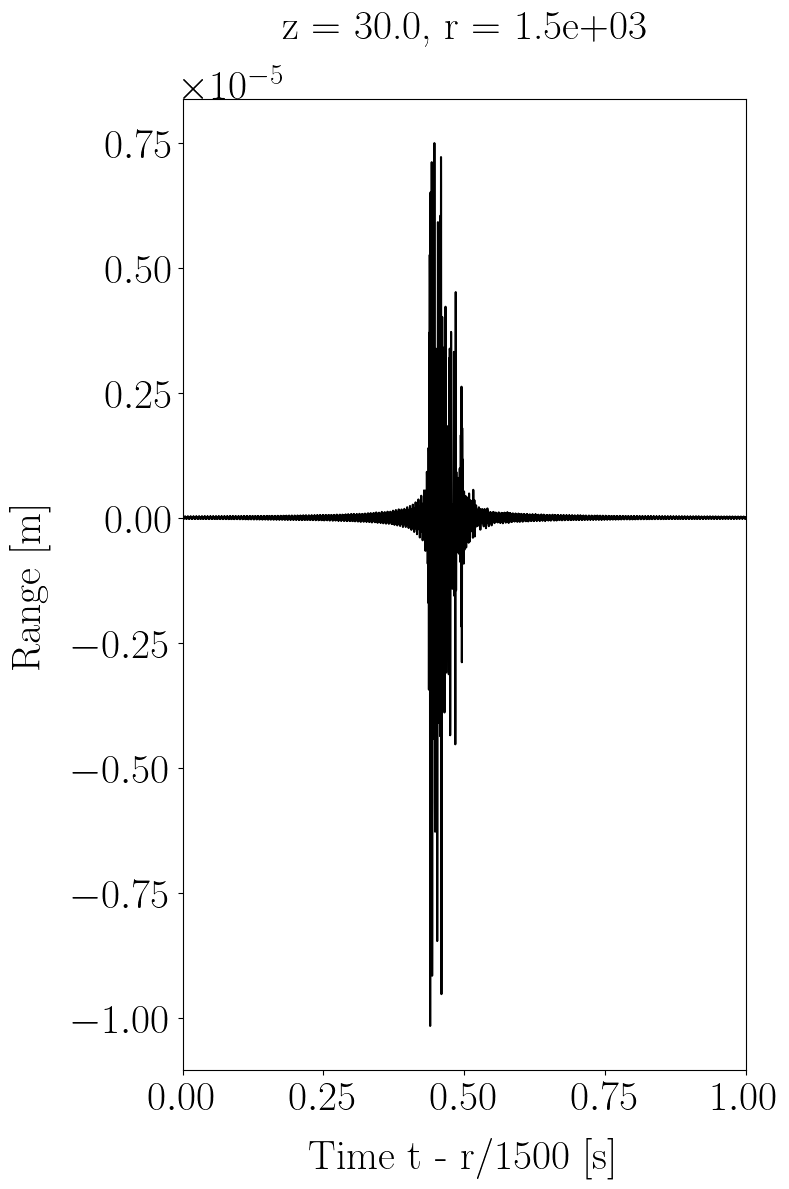

In [163]:
z_plot = bathy.bathy_depth.max() - 1
r_plot = bathy.bathy_range.max() * 1e3

ts = ds_ir.t.diff("t").values[0]
tau_roll = r_plot / g.c0 # Roll time axis to start at zero 

print(f"R = {r_plot}m, tau = {tau_roll}s")
idx_tau_roll = tau_roll / ts
idx_tau_roll = idx_tau_roll.astype(int)

# Scale for visualization
max_amplitude = ds_ir.s.max().values
# alpha_dilatation = 1 * r_offset
# ds_ir["s"] = ds_ir.s / max_amplitude * alpha_dilatation

plt.figure(figsize=(8, 12))
# Get ir at rplot, zplot
sig = ds_ir.s.sel(r=r_plot, z=z_plot, method="nearest")

# Roll over time axis for current range
sig_roll = sig.roll(t=-idx_tau_roll, roll_coords=False)
sig_roll.plot(color="k")

plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("Range [m]")
plt.xlim([0, 1])



## Durée de réverberation

$T_{60 \text{dB}}$ est défini comme le temps nécessaire pour que l'énergie acoustique décroisse de 60 dB 


Définition du SPL : 

$ SPL = 10 \log{ \frac{1}{p_0^2} \times \frac{1}{T} \int_0^{T} p(t)^2 dt}$

ou encore, 

$ SPL = 20 \log{ \frac{p_{rms}}{p_0} } $

avec, 

$p_{rms} \approx \sqrt{\frac{1}{K} \sum_{k=1}^{K} p[k]^2} $

Window duration for RMS: 0.01 s


(0.0, 4.0)

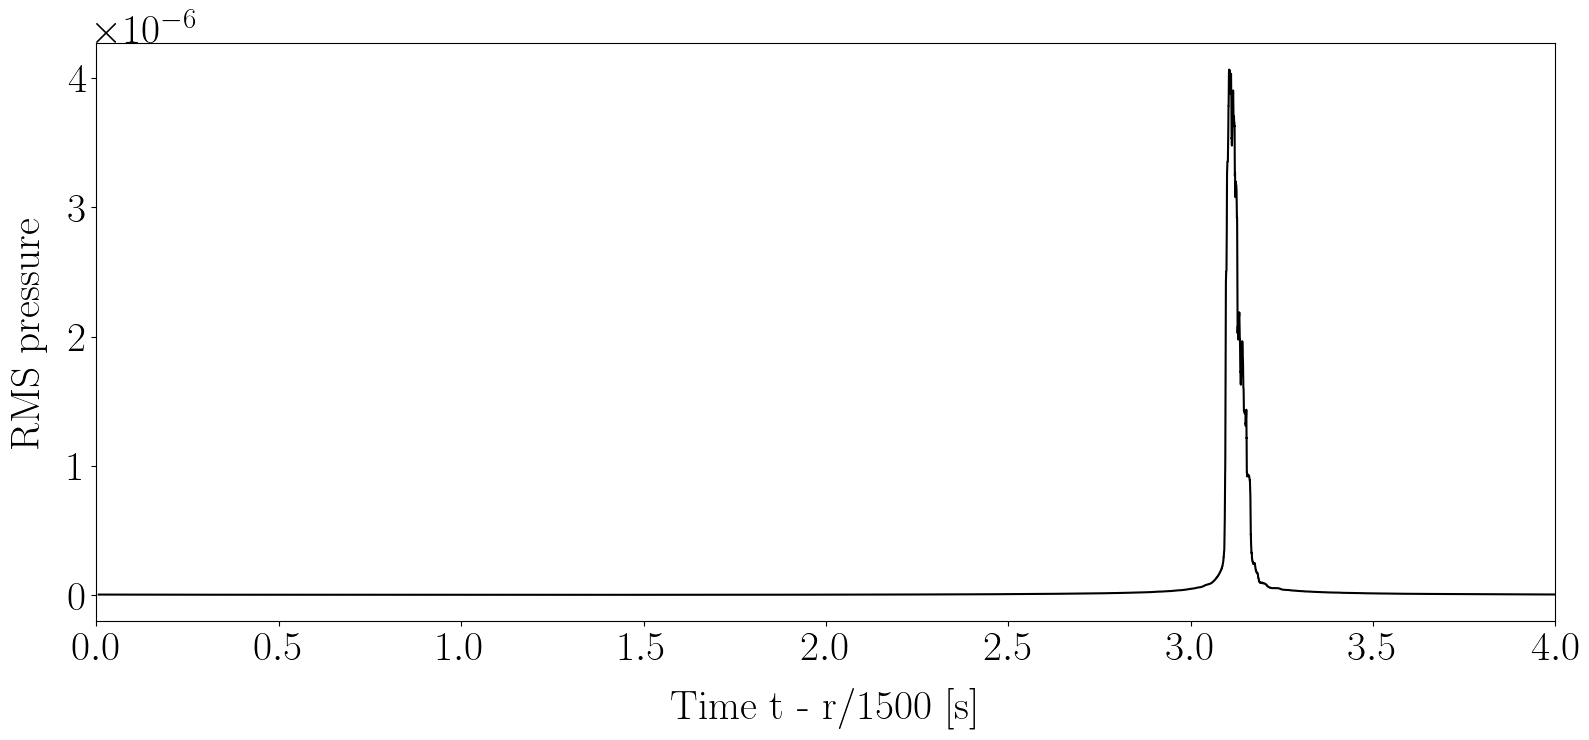

In [151]:
# Derive prms
p = sig_roll
t_win = 100
# print(f"Window size for RMS: {t_win} samples")
print(f"Window duration for RMS: {t_win * ts:.2f} s")
p2_roll = (p**2).rolling(t=t_win, center=True).mean()  
p_rms = np.sqrt(p2_roll)

# Plot p_rms
plt.figure()
p_rms.plot(color="k")
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel("RMS pressure")
plt.title("")
plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts

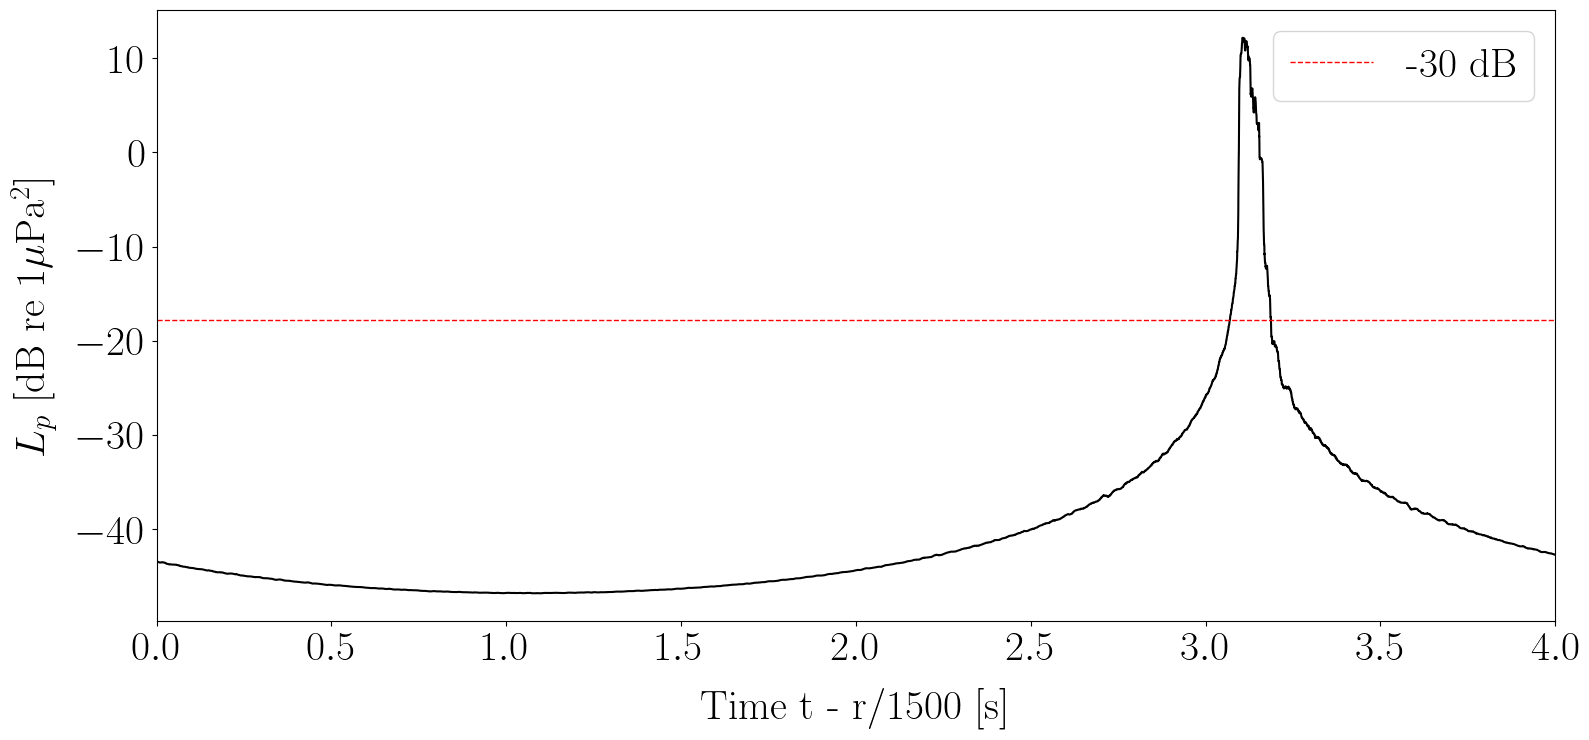

In [152]:
# Derive SPL
# p_rms /= p_rms.max().values
spl = 20 * np.log10(p_rms / g.p0)

# Plot spl
spl.plot(color="k")

# Add threshold line
threshold = -30  # Threshold in dB
th = np.max(spl).values + threshold
plt.axhline(
    y=th,
    color="r",
    linestyle="--",
    linewidth=1,
    label=f"{threshold} dB",
)


plt.xlim([0, 4])  # Cropp the end to avoid wrapped around signal artefacts
plt.xlabel(f"Time  t - r/{g.c0} [s]")
plt.ylabel(r"$L_p$ [dB re 1$\mu$Pa$^2$]")
plt.legend()
plt.title("")

# Save figure as pdf
fpath = os.path.join(img_folder_path, f"{name}_ir_Lp_{r_plot:.0f}m.pdf")
plt.savefig(fpath)

In [153]:
# Derive tau_th 
tau_th = spl.t.where(spl < th).dropna("t").values[0]
print(f"Reverberation time ({threshold} dB) : {tau_th:.2f} s")

Reverberation time (-30 dB) : 0.01 s
